# ESM C Implementation (62% Train Spearman R, 43% Validation Spearman R)

Within each cycle of active learning:

1. Collect training data (original training data + your query data).

2. Train a prediction model to predict the DMS_score for each mutant (e.g., M0A).

3. Use the trained model to predict the score for all mutant in the test set.

4. Select query mutants for next round based on certain criteria. You may want to make sure you don't query the same mutant twice as you only have limited chances to make queries.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, Dataset
import random
from copy import deepcopy
import pandas as pd
from scipy.stats import spearmanr
import argparse
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression

import os
from tqdm.auto import tqdm

from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig

## 1. Collect Training Data

In [2]:
#with open('Hackathon_data/Hackathon_data/sequence.fasta', 'r') as f:
with open('sequence.fasta', 'r') as f:
  data = f.readlines()

sequence_wt = data[1].strip()
sequence_wt

'MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLREKMRRRLESGDKWFSLEFFPPRTAEGAVNLISRFDRMAAGGPLYIDVTWHPAGDPGSDKETSSMMIASTAVNYCGLETILHMTCCRQRLEEITGHLHKAKQLGLKNIMALRGDPIGDQWEEEEGGFNYAVDLVKHIRSEFGDYFDICVAGYPKGHPEAGSFEADLKHLKEKVSAGADFIITQLFFEADTFFRFVKACTDMGITCPIVPGIFPIQGYHSLRQLVKLSKLEVPQEIKDVIEPIKDNDAAIRNYGIELAVSLCQELLASGLVPGLHFYTLNREMATTEVLKRLGMWTEDPRRPLPWALSAHPKRREEDVRPIFWASRPKSYIYRTQEWDEFPNGRWGNSSSPAFGELKDYYLFYLKSKSPKEELLKMWGEELTSEESVFEVFVLYLSGEPNRNGHKVTCLPWNDEPLAAETSLLKEELLRVNRQGILTINSQPNINGKPSSDPIVGWGPSGGYVFQKAYLEFFTSRETAEALLQVLKKYELRVNYHLVNVKGENITNAPELQPNAVTWGIFPGREIIQPTVVDPVSFMFWKDEAFALWIERWGKLYEEESPSRTIIQYIHDNYFLVNLVDNDFPLDNCLWQVVEDTLELLNRPTQNARETEAP'

In [3]:
len(sequence_wt)

656

In [4]:
def get_mutated_sequence(mut, sequence_wt):
    '''
    Adds the specified mutation into the wild-type sequence.

    Params:
        mut (str): The mutation to be applied.
        sequence_wt (str): The wild-type sequence to which the mutation will be applied.
    Returns:
        A deep copy of the mutated sequence string.
    '''
    # wt - wild type; pos - position; mt - mutation
    wt, pos, mt = mut[0], int(mut[1:-1]), mut[-1]

    sequence = deepcopy(sequence_wt)

    return sequence[:pos] + mt + sequence[pos+1:]

In [5]:
#df_train = pd.read_csv('Hackathon_data/Hackathon_data/train.csv')
df_train = pd.read_csv('train.csv')
df_train['sequence'] = df_train.mutant.apply(lambda x: get_mutated_sequence(x, sequence_wt))
df_train

,mutant,DMS_score,sequence
0,M0Y,0.2730,YVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1,M0W,0.2857,WVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
2,M0V,0.2153,VVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
3,M0T,0.3122,TVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
4,M0S,0.2180,SVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
...,...,...,...
1135,P347D,0.3876,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1136,P347C,0.1837,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1137,P347A,0.4611,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1138,P347M,0.2412,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...


In [6]:
#df_test = pd.read_csv('Hackathon_data/Hackathon_data/test.csv')
df_test = pd.read_csv('test.csv')
df_test['sequence'] = df_test.mutant.apply(lambda x: get_mutated_sequence(x, sequence_wt))
df_test

,mutant,sequence
0,V1D,MDNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1,V1Y,MYNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
2,V1C,MCNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
3,V1A,MANEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
4,V1E,MENEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
...,...,...
11319,P655S,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
11320,P655T,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
11321,P655V,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
11322,P655A,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...


In [7]:
# TODO: integrate the query data that you acquired each round into df_train

## 2. Train a Prediction Model

### Hyperparameters

In [8]:
seq_length = 656
seed = 0 # seed for splitting the validation set
val_ratio = 0.2 # proportion of validation set

### ProteinDataset
Convert amino acids to machine-readable data via embedding space.

In [9]:
def gen_emb_from_df(df, out_dir="esm_c_embeddings_variants", device="cuda:0", batch_size=8):
    '''
    Generate and cache ESM-C sequence embeddings for each unique mutant.
    Saves one mean-pooled embedding tensor per mutant to out_dir/{mutant}.pt.
    '''
    os.makedirs(out_dir, exist_ok=True)

    if isinstance(device, torch.device):
        use_cuda = device.type == "cuda"
    else:
        use_cuda = str(device).startswith("cuda")
    device = torch.device(device) if not isinstance(device, torch.device) else device

    # Each item is (name_for_file, sequence)
    data = [(m, s[:1000]) for m, s in df[["mutant", "sequence"]].drop_duplicates().values]
    print(f"Number of unique variants: {len(data)}")

    # Instantiate 600-million-parameter ESM-C model
    model = ESMC.from_pretrained("esmc_600m").to(device).eval()
    if use_cuda:
        model.half()  # Half-prec. to reduce GPU memory and runtime

    for i in tqdm(range(int(np.ceil(len(data) / batch_size)))):
        batch = data[i * batch_size:(i + 1) * batch_size]

        # Cache skip
        if all(os.path.exists(os.path.join(out_dir, f"{name}.pt")) for name, _ in batch):
            continue

        for name, sequence in batch:
            path = os.path.join(out_dir, f"{name}.pt")
            if os.path.exists(path):
                continue

            protein = ESMProtein(sequence=sequence)

            with torch.no_grad():
                protein_tensor = model.encode(protein)
                model_output = model.logits(
                    protein_tensor,
                    LogitsConfig(sequence=True, return_embeddings=True),
                )

            seq_emb = model_output.embeddings

            # Handle both [L, D] and [1, L, D] output shapes.
            if seq_emb.ndim == 3:
                seq_emb = seq_emb[0]
            seq_mean = seq_emb.float().mean(dim=0).detach().cpu()

            torch.save(seq_mean, path)

class DmsESMDataset(Dataset):
    def __init__(self, df, emb_dir, is_train=True):
        self.df = df.reset_index(drop=True)
        self.emb_dir = emb_dir
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        mutant = self.df.loc[idx, "mutant"]
        emb = torch.load(os.path.join(self.emb_dir, f"{mutant}.pt")).float()
        if self.is_train:
            y = torch.tensor(self.df.loc[idx, "DMS_score"], dtype=torch.float32)
            return emb, y
        return emb, torch.tensor(0.0, dtype=torch.float32)

In [10]:
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("No CUDA device found; using CPU.")

# Run on GPU 0 when available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

True
NVIDIA GeForce RTX 5070 Laptop GPU


In [11]:
# Combine our datasets for embedding, them split them into train / test sets afterward. Each has mutated sequence variants stored as a separate .pt embedding.
all_df = pd.concat(
    [df_train[["mutant", "sequence"]], df_test[["mutant", "sequence"]]],
    ignore_index=True
).drop_duplicates("mutant")

gen_emb_from_df(all_df, out_dir="esm_c_embeddings_variants", device=device, batch_size=8)

Number of unique variants: 12464


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/1558 [00:00<?, ?it/s]

In [12]:
# gen_emb('Hackathon_Data/Hackathon_data/sequence.fasta', out_dir='esm_embeddings_train')
# gen_emb('Hackathon_Data/Hackathon_data/', out_dir='esm_embeddings_test')

In [ ]:
# Use simple MLP model to predict from ESM C embeddings.
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=768, dropout_p=0.26, num_layers=5):
        super().__init__()

        num_layers = max(1, int(num_layers))
        hidden_dim = int(hidden_dim)

        layers = []
        prev_dim = input_dim
        curr_dim = hidden_dim

        for layer_idx in range(num_layers):
            # Keep layer widths consistent by explicitly tracking in/out dims.
            if layer_idx == 0:
                next_dim = curr_dim
            elif ((num_layers-1) % 2 == 0) and (layer_idx == (num_layers-1) / 2):   # If an odd dimension, keep dimension constant for middle layer.
                next_dim = curr_dim
            elif layer_idx < num_layers / 2:
                next_dim = curr_dim * 2
            else:
                next_dim = curr_dim // 2

            layers.extend([
                nn.Linear(prev_dim, next_dim),
                nn.BatchNorm1d(next_dim),
                nn.ReLU(),
                nn.Dropout(dropout_p),
            ])

            prev_dim = next_dim
            curr_dim = next_dim

        self.layers = nn.Sequential(
            *layers,
            nn.Linear(prev_dim, 1),
        )

    def forward(self, x):
        return self.layers(x).squeeze(-1)

In [30]:
'''
Params:
    model (torch.nn):               The untrained Fully-Connected Neural Network (FCN)
    train_dataset (DmsESMDataset):  The training dataset
    val_dataset (DmsESMDataset):    The validation dataset
    epochs (int):                   The number of epochs over which to train
    batch_size (int):               The number of batches in which to split the input data
    lr (float):                     The learning rate
    patience (int):                 The number of epochs to wait while the validation metric shows no improvement
    alpha (float):                  The Exponential Moving Average (EMA) weight by which the Spearman R is smoothed
    device (str):                   The CPU / GPU on which to run the model
Returns:
    model (torch.nn):               The trained FCN
    best_ckpt (dictionary):         Dictionary saving the best parameters
    train_losses (list):            Per-epoch training losses
    val_losses (list):              Per-epoch validation losses
'''
def train_model_esm(model, train_dataset, val_dataset, epochs=100, batch_size=256, lr=1e-3, patience=20, alpha=0.3, device='cuda:0'):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Use MSE loss to handle bounded regression.
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=8)

    best_val_spearman = -np.inf
    best_ckpt = None
    patience_counter = 0
    val_spearman_ema = None

    # History lists for plotting (one scalar per epoch).
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()

        # Per-epoch collectors.
        epoch_train_losses = []
        epoch_train_preds = []
        epoch_train_targets = []

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device).float()

            optimizer.zero_grad()
            outputs = model(inputs).squeeze(-1)
            loss = criterion(outputs, targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0, norm_type=2.0)
            optimizer.step()

            epoch_train_losses.append(loss.item())
            epoch_train_preds.append(outputs.detach().cpu())
            epoch_train_targets.append(targets.detach().cpu())

        train_preds_np = torch.cat(epoch_train_preds).numpy()
        train_targets_np = torch.cat(epoch_train_targets).numpy()
        train_spearman = spearmanr(train_preds_np, train_targets_np).statistic

        # Validation
        model.eval()
        epoch_val_losses = []
        epoch_val_preds = []
        epoch_val_targets = []
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs = inputs.to(device)
                targets = targets.to(device).float()
                outputs = model(inputs).squeeze(-1)

                epoch_val_losses.append(criterion(outputs, targets).item())
                epoch_val_preds.append(outputs.detach().cpu())
                epoch_val_targets.append(targets.detach().cpu())

        val_preds_np = torch.cat(epoch_val_preds).numpy()
        val_targets_np = torch.cat(epoch_val_targets).numpy()
        val_spearman = spearmanr(val_preds_np, val_targets_np).statistic
        mean_train_loss = float(np.mean(epoch_train_losses))
        mean_val_loss = float(np.mean(epoch_val_losses))

        # Save per-epoch losses for plotting.
        train_losses.append(mean_train_loss)
        val_losses.append(mean_val_loss)

        if np.isnan(train_spearman):
            train_spearman = 0.0
        if np.isnan(val_spearman):
            val_spearman = -1.0

        # Initialize EMA on first epoch, then update.
        if val_spearman_ema is None:
            val_spearman_ema = val_spearman
        else:
            val_spearman_ema = alpha * val_spearman + (1 - alpha) * val_spearman_ema

        scheduler.step(val_spearman_ema)

        print(
            f"Epoch {epoch+1}: "
            f"Train Loss={mean_train_loss:.4f}, Train Spearman={train_spearman:.4f}, "
            f"Val Loss={mean_val_loss:.4f}, Val Spearman={val_spearman:.4f}, "
            f"LR={optimizer.param_groups[0]['lr']:.6g}"
        )

        # Early stopping on validation Spearman (ranking quality)
        if val_spearman_ema > best_val_spearman:
            best_val_spearman = val_spearman_ema
            best_ckpt = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    if best_ckpt is None:
        best_ckpt = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    return model, best_ckpt, train_losses, val_losses

In [31]:
# Build only the test dataset/loader here; train/val splits are created per CV fold.
n_splits = 5
test_ds = DmsESMDataset(df_test, "esm_c_embeddings_variants", is_train=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

In [ ]:
# --------------- Train our model with 5-fold cross-validation ---------------
kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
indices = np.arange(len(df_train))

fold_train_losses = []
fold_val_losses = []
fold_val_spearmans = []
fold_checkpoints = []

for fold, (train_idx, val_idx) in enumerate(kf.split(indices), start=1):
    print(f"\n========== Fold {fold}/{n_splits} ==========")

    df_train_split = df_train.iloc[train_idx].reset_index(drop=True)
    df_val_split = df_train.iloc[val_idx].reset_index(drop=True)

    train_ds = DmsESMDataset(df_train_split, "esm_c_embeddings_variants", is_train=True)
    val_ds = DmsESMDataset(df_val_split, "esm_c_embeddings_variants", is_train=True)

    model_fold = MLPRegressor().to(device)
    model_fold, best_ckpt_fold, train_losses_fold, val_losses_fold = train_model_esm(
        model_fold,
        train_ds,
        val_ds,
        epochs=500,
        batch_size=256,
        lr=1e-4,
        patience=30,
        device=device,
    )
    model_fold.load_state_dict(best_ckpt_fold)

    # Evaluate each fold checkpoint on its held-out fold to pick a single best checkpoint.
    val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
    fold_preds = []
    fold_targets = []
    model_fold.eval()
    with torch.no_grad():
        for sequences, targets in val_loader:
            sequences = sequences.to(device)
            outputs = model_fold(sequences).squeeze(-1).detach().cpu().numpy()
            fold_preds.extend(outputs.tolist())
            fold_targets.extend(targets.numpy().tolist())

    fold_val_spearman = spearmanr(fold_preds, fold_targets).statistic
    if np.isnan(fold_val_spearman):
        fold_val_spearman = -1.0

    fold_train_losses.append(train_losses_fold)
    fold_val_losses.append(val_losses_fold)
    fold_val_spearmans.append(float(fold_val_spearman))
    fold_checkpoints.append(best_ckpt_fold)

    print(f"Fold {fold} best val Spearman: {fold_val_spearman:.4f}")

# Aggregate variable-length loss curves for plotting.
max_epochs = max(len(losses) for losses in fold_train_losses)

def mean_curve(curves, max_len):
    arr = np.full((len(curves), max_len), np.nan, dtype=np.float32)
    for i, curve in enumerate(curves):
        arr[i, :len(curve)] = curve
    return np.nanmean(arr, axis=0).tolist()

train_losses = mean_curve(fold_train_losses, max_epochs)
val_losses = mean_curve(fold_val_losses, max_epochs)

best_fold_idx = int(np.argmax(fold_val_spearmans))
best_val_spearman = fold_val_spearmans[best_fold_idx]
best_ckpt_esm = fold_checkpoints[best_fold_idx]

print("\nCross-validation fold Spearman scores:", np.round(fold_val_spearmans, 4))
print(f"Best fold: {best_fold_idx + 1}/{n_splits} (Spearman={best_val_spearman:.4f})")

# Keep one trained model object loaded with the best fold checkpoint.
model_esm = MLPRegressor().to(device)
model_esm.load_state_dict(best_ckpt_esm)


# --------------- Test our model by fold ensembling ---------------
preds_per_fold = []
for fold_idx, ckpt in enumerate(fold_checkpoints, start=1):
    model_fold = MLPRegressor().to(device)
    model_fold.load_state_dict(ckpt)
    model_fold.eval()

    fold_test_preds = []
    with torch.no_grad():
        for sequences, _ in test_loader:
            sequences = sequences.to(device)
            outputs = model_fold(sequences).squeeze(-1).detach().cpu().numpy()
            fold_test_preds.extend(outputs.tolist())
    preds_per_fold.append(fold_test_preds)
    print(f"Collected test predictions from fold {fold_idx}/{n_splits}")

preds = np.mean(np.array(preds_per_fold), axis=0).tolist()

df_pred = df_test.copy()
df_pred["DMS_score_predicted"] = preds


========== Fold 1/5 ==========
Epoch 1: Train Loss=0.3081, Train Spearman=-0.0360, Val Loss=0.1600, Val Spearman=-0.1169, LR=0.0001
Epoch 2: Train Loss=0.2520, Train Spearman=0.0705, Val Loss=0.1675, Val Spearman=0.0622, LR=0.0001
Epoch 3: Train Loss=0.2077, Train Spearman=0.0925, Val Loss=0.1387, Val Spearman=0.1729, LR=0.0001
Epoch 4: Train Loss=0.1634, Train Spearman=0.0880, Val Loss=0.1035, Val Spearman=0.2137, LR=0.0001
Epoch 5: Train Loss=0.1817, Train Spearman=0.0506, Val Loss=0.0708, Val Spearman=0.2359, LR=0.0001
Epoch 6: Train Loss=0.1681, Train Spearman=0.0472, Val Loss=0.0536, Val Spearman=0.2241, LR=0.0001
Epoch 7: Train Loss=0.1663, Train Spearman=0.0009, Val Loss=0.0497, Val Spearman=0.2516, LR=0.0001
Epoch 8: Train Loss=0.1581, Train Spearman=0.1078, Val Loss=0.0537, Val Spearman=0.2105, LR=0.0001
Epoch 9: Train Loss=0.1539, Train Spearman=0.1412, Val Loss=0.0508, Val Spearman=0.1429, LR=0.0001
Epoch 10: Train Loss=0.1570, Train Spearman=0.0555, Val Loss=0.0515, Val Sp

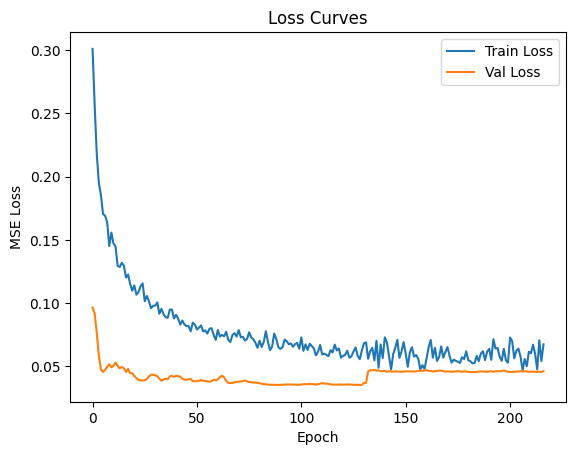

In [33]:
import matplotlib.pyplot as plt

# Plot losses in order to make sure the model isn't overfitting.
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title('Loss Curves')
plt.ylabel('MSE Loss')
plt.xlabel('Epoch')
plt.legend()

In [34]:
# Show current ESM-based predictions.
df_pred[['mutant', 'DMS_score_predicted']].head(n=10)

,mutant,DMS_score_predicted
0,V1D,0.515324
1,V1Y,0.409204
2,V1C,0.350101
3,V1A,0.559199
4,V1E,0.458608
5,V1W,0.126473
6,V1T,0.491287
7,V1R,0.378136
8,V1Q,0.442836
9,V1S,0.580032


In [35]:
# Save predictions to .csv.
df_pred[['mutant', 'DMS_score_predicted']].to_csv('test_predictions.csv', index=False)

In [36]:
group_number = "1"

with open("GroupName.txt", "w") as f:
    f.write(group_number.strip() + "\n")

print("Saved GroupName.txt")

Saved GroupName.txt


In [37]:
api_key = "df303a548bec1afcff7d7196650c5396cfa74c94a8be5357043602dcc7537ba7"

with open("APIKey.txt", "w") as f:
    f.write(api_key.strip() + "\n")

print("Saved APIKey.txt")

Saved APIKey.txt


## 3. Select Query for Next Round

In [38]:
# Show prediction distribution.
df_pred.sort_values('DMS_score_predicted', ascending=False)

,mutant,sequence,DMS_score_predicted
10375,T606Q,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.784826
10781,L627E,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.774034
10104,I591A,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.762053
10093,I591Q,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.759469
776,H41A,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERAERLR...,0.747152
...,...,...,...
1144,E62L,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,-0.051642
1148,E62R,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,-0.057015
1157,E62F,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,-0.083985
1143,E62K,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,-0.095808


In [39]:
# Write mutants with top ten DMS scores to .txt file.
df_top_ten = df_pred.sort_values('DMS_score_predicted', ascending=False).head(n=10)
df_top_ten.to_csv('top10.txt', columns=['mutant'], index=False, header=False)
print(df_top_ten)

      mutant                                           sequence  \
10375  T606Q  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
10781  L627E  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
10104  I591A  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
10093  I591Q  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
776     H41A  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERAERLR...   
10776  L627R  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
8994   L533Q  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
10789  L627P  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
10790  L627Q  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
1538    M82L  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   

       DMS_score_predicted  
10375             0.784826  
10781             0.774034  
10104             0.762053  
10093             0.759469  
776               0.747152  
10776             0.744217  
8994              0.742316  
10789             0.740622  
1

In [40]:
# Example: randomly select 100 test variants to be queried.
# Note: Random selection may not be a good strategy
# TODO: Select query mutants for the next round based on your own criteria

queries = np.random.choice(df_test.mutant.values, size=100, replace=False)
queries

array(['S303R', 'K287I', 'F616G', 'P442Q', 'E330Y', 'G386N', 'S429K',
       'V449K', 'A586W', 'E432Y', 'Q259L', 'L525A', 'I124Q', 'K543G',
       'E42V', 'L399C', 'V282F', 'V473E', 'K448I', 'N619E', 'K214Y',
       'V430G', 'K179Q', 'Y437L', 'L553K', 'R81A', 'R518C', 'F64T',
       'K596A', 'E46L', 'I293D', 'K543P', 'R43K', 'K57A', 'G170H',
       'G101H', 'H612E', 'E398D', 'A83W', 'T93S', 'S102N', 'E359W',
       'L399V', 'A301F', 'K355V', 'L533G', 'A327L', 'E382P', 'L36W',
       'Q259Y', 'P551R', 'R45T', 'G489Q', 'D288T', 'Y531E', 'R294F',
       'Q526D', 'Y375K', 'F383C', 'A649R', 'L416G', 'L52V', 'R534F',
       'F238P', 'D613A', 'D613C', 'S60I', 'V1T', 'N629M', 'E330F',
       'A203F', 'P34C', 'E513L', 'T572Q', 'G35H', 'L589T', 'R237K',
       'K287D', 'G21M', 'S20Q', 'T329N', 'K104Q', 'A523T', 'S17C', 'T68V',
       'R78L', 'S205Q', 'P342C', 'N385I', 'P159E', 'H262A', 'K240W',
       'L322M', 'I286M', 'D56W', 'S183G', 'E299I', 'L155Q', 'D176P',
       'A72W'], dtype=object)

In [41]:
with open('query.txt', 'w') as f:
  for mutant in queries:
    f.write(mutant+'\n')